# Machine Learning
A branch of Artificial Intelligence which focuses on developing models and algorithms that enable a computer to learn from data on its own without explicit programming.

## Data Preprocessing
Before training a model, we need data to train it. The model trains well when the data is clean, organized and noise-free. This process of **cleaning**, **transforming** and **organizing** raw data into a clean, consistent and structured format, that ML models can use effectively, is known as data preprocessing.

Large data sets are used to train models so they generalise well. There are different sources where they can be sourced from, such as UCI Machine Learning Repository(hosted by the University of California,Irvine), Kaggle, etc

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### Citation 
A formal refernce to a source of information. 
Why am I mentioning this here? Because we use data from different sources and in projects citations would be required to verify the data if we pick it up from somewhere. 

There are different styles of citations for different uses : 

- APA (American Psuchological Association) : used in psychology, education and social sciences
- MLA (Modern Language Association) : humaities, literature and arts
- Chicago : commonly history, sometimes humaities
- IEEE (Institute of Electrical and Electronic Engineers) : engineering and technical fields
- Vancouver - biomedical, health and general science fields

### Citing the data set used here

R. Bock. "MAGIC Gamma Telescope," UCI Machine Learning Repository, 2004. [Online]. Available: https://doi.org/10.24432/C52C8B.

### Importing the data set 

In [22]:
cols= ["fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]
df = pd.read_csv("magic+gamma+telescope/magic04.data", names=cols)
print(df)

#print(df.head()) #print the first five records

        fLength    fWidth   fSize   fConc  fConc1     fAsym   fM3Long  \
0       28.7967   16.0021  2.6449  0.3918  0.1982   27.7004   22.0110   
1       31.6036   11.7235  2.5185  0.5303  0.3773   26.2722   23.8238   
2      162.0520  136.0310  4.0612  0.0374  0.0187  116.7410  -64.8580   
3       23.8172    9.5728  2.3385  0.6147  0.3922   27.2107   -6.4633   
4       75.1362   30.9205  3.1611  0.3168  0.1832   -5.5277   28.5525   
...         ...       ...     ...     ...     ...       ...       ...   
19015   21.3846   10.9170  2.6161  0.5857  0.3934   15.2618   11.5245   
19016   28.9452    6.7020  2.2672  0.5351  0.2784   37.0816   13.1853   
19017   75.4455   47.5305  3.4483  0.1417  0.0549   -9.3561   41.0562   
19018  120.5135   76.9018  3.9939  0.0944  0.0683    5.8043  -93.5224   
19019  187.1814   53.0014  3.2093  0.2876  0.1539 -167.3125 -168.4558   

       fM3Trans   fAlpha     fDist class  
0       -8.2027  40.0920   81.8828     g  
1       -9.9574   6.3609  205.2610   

The class column is the column which classifies the particle as gamma(g) or hadron(h)

In [23]:
print(df["class"].unique()) #lists out the unique values in the column "class"

#converting the class column to a bool data type to classify gamma or hadron particles
df["class"] = (df["class"]== 'g').astype(int)
print(df["class"].unique())

print(df)

<StringArray>
['g', 'h']
Length: 2, dtype: str
[1 0]
        fLength    fWidth   fSize   fConc  fConc1     fAsym   fM3Long  \
0       28.7967   16.0021  2.6449  0.3918  0.1982   27.7004   22.0110   
1       31.6036   11.7235  2.5185  0.5303  0.3773   26.2722   23.8238   
2      162.0520  136.0310  4.0612  0.0374  0.0187  116.7410  -64.8580   
3       23.8172    9.5728  2.3385  0.6147  0.3922   27.2107   -6.4633   
4       75.1362   30.9205  3.1611  0.3168  0.1832   -5.5277   28.5525   
...         ...       ...     ...     ...     ...       ...       ...   
19015   21.3846   10.9170  2.6161  0.5857  0.3934   15.2618   11.5245   
19016   28.9452    6.7020  2.2672  0.5351  0.2784   37.0816   13.1853   
19017   75.4455   47.5305  3.4483  0.1417  0.0549   -9.3561   41.0562   
19018  120.5135   76.9018  3.9939  0.0944  0.0683    5.8043  -93.5224   
19019  187.1814   53.0014  3.2093  0.2876  0.1539 -167.3125 -168.4558   

       fM3Trans   fAlpha     fDist  class  
0       -8.2027  40.0920  

## Visualizing the data 

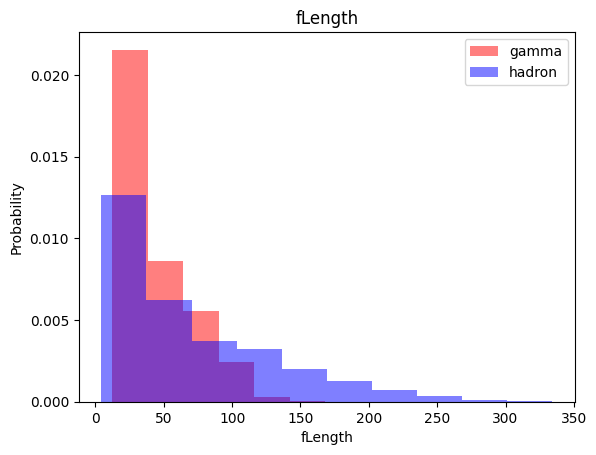

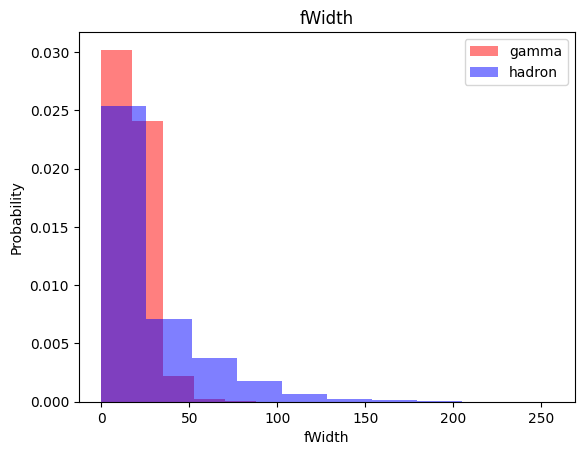

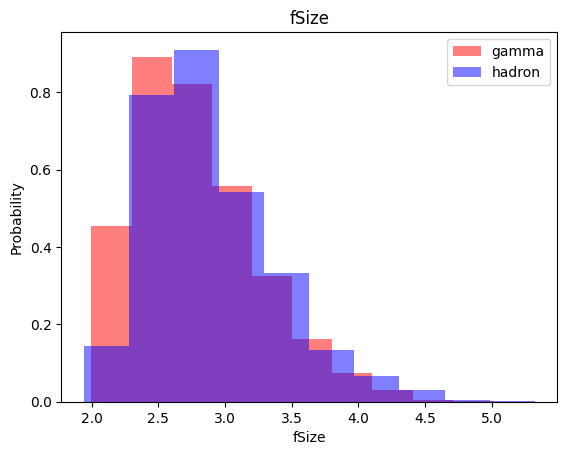

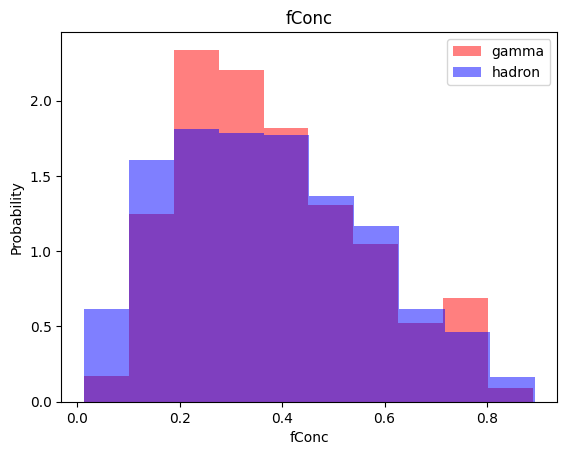

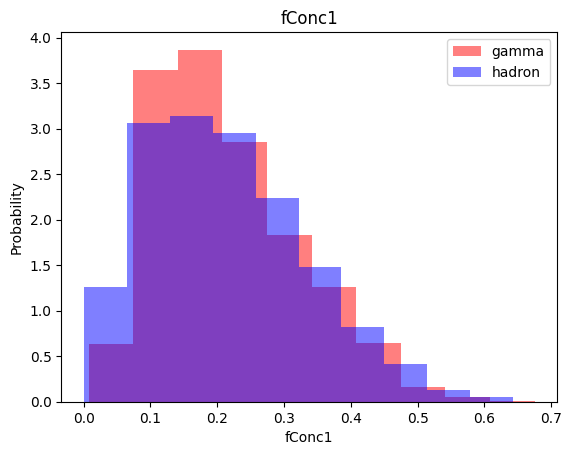

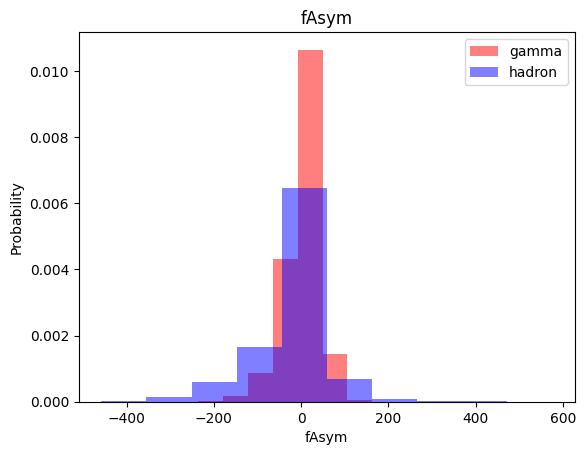

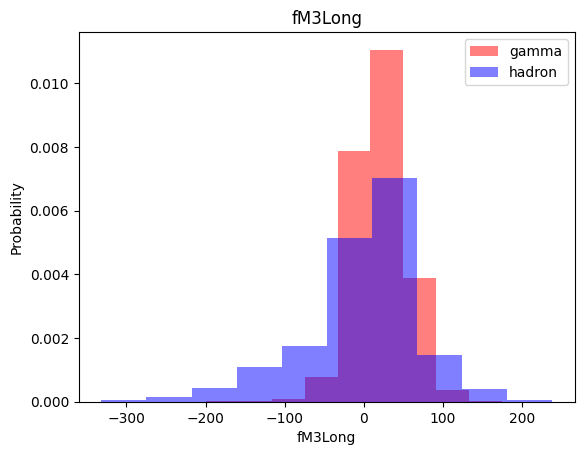

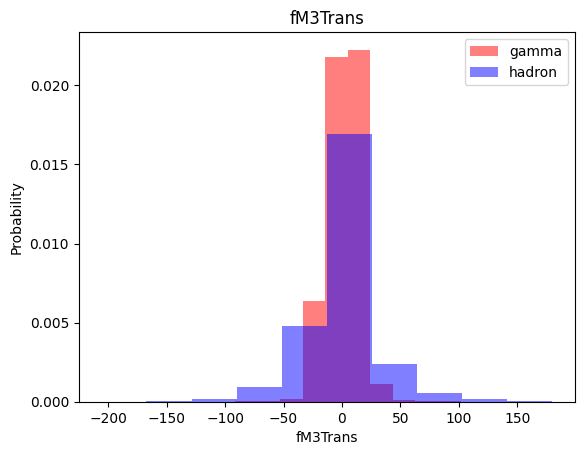

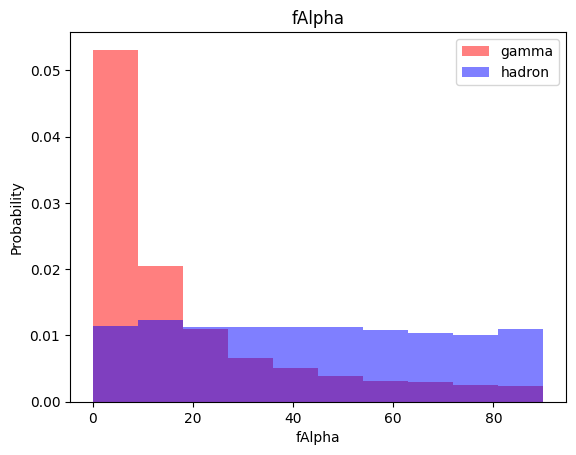

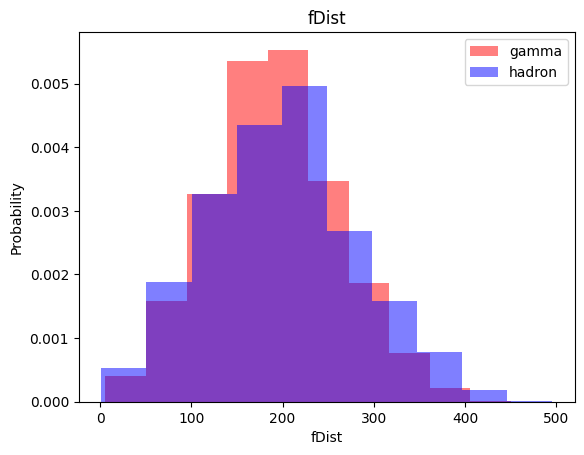

In [35]:
#Plotting the histograms for both the particle, individually for each feature
for colName in cols[:-1] : #for each column 
    #plot histogram
    plt.hist(df[df["class"] == 1][colName], color="red", label="gamma", alpha=0.5, density= True) #alpha : transparency , density : normalizes the distribution
    plt.hist(df[df["class"] == 0][colName], color="blue", label="hadron", alpha=0.5, density= True)
    plt.title(colName)
    plt.ylabel("Probability")
    plt.xlabel(colName)
    plt.legend()
    plt.show()

## Training, validation and testing datasets

In [84]:
#.split(dataframe, [split point 1, split point 2, ... split point n-1])
train, validation, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))]) # sample() -> shuffles given fraction of data

#The above function splits the data up but converts them to numpy arrays
#so we convert them back to pandas dataframes
train = pd.DataFrame(train, columns=df.columns)
validation = pd.DataFrame(validation, columns=df.columns)
test = pd.DataFrame(test, columns=df.columns)

print(train[train["class"] == 1])

        fLength   fWidth   fSize   fConc  fConc1     fAsym  fM3Long  fM3Trans  \
1       33.5735  17.9992  2.5321  0.3906  0.2247  -45.0144  24.2938   -4.0172   
3       34.9632  20.9011  2.7885  0.3092  0.1961  -12.3630  21.8051   14.5036   
5       51.2161  23.5687  2.7156  0.2907  0.1761  -86.5928  37.2872  -22.0663   
8       20.2919  16.2356  2.6004  0.4768  0.2999    8.9987  -6.3068  -10.4155   
11      19.6147   7.4136  2.0881  0.7347  0.4286    1.2375  -7.0857   -4.8478   
...         ...      ...     ...     ...     ...       ...      ...       ...   
11402   28.9665  11.8606  2.4800  0.4007  0.2003   -0.6387  18.0788   -9.4519   
11403   23.1655  20.9149  2.6590  0.4079  0.2292   16.1363  17.7383   14.8946   
11406   20.5175  12.9460  2.4616  0.5043  0.2539   17.0192   4.8579   -4.1418   
11407  100.7470  16.6321  2.9440  0.3322  0.2110 -110.4110  74.4191  -14.7132   
11408   20.2358   7.1978  2.1089  0.7549  0.3774    3.9409 -11.5931   -5.4469   

        fAlpha     fDist  c

## Scaling feature values

The numeric value of one feature might have a very huge gap in their scale. ex - one might be in 100s while other in decimals (<0). This may result in one feature having more 'weight' than the other for no reason. Hence data is scaled.

Usually done using StandardScaler() class from the preprocessing module of the sklearn library. It uses the z-score normalization, i.e., subtracts the mean values from the data, then divides by the standard deviation. => z = x-u/sigma, z is the new, normalized data value. It is important so that each feature has the same scale and its contribution is decided by its corresponding weight and not its scale.

In [ ]:
# THIS IS WRITTEN AGAIN WITH MODIFICATION AFTER THE IMBLEARN SECTION SO THAT WE SCALE THE DATA AFTER THE CLASSES ARE BALANCED AND NOT BIASED TOWARDS ANY ONE OF THE CLASSES


# from sklearn.preprocessing import StandardScaler

# def scale_dataset(dataframe):
#     X = dataframe[dataframe.cols[:-1].values]
#     Y = dataframe[dataframe.cols[-1].values]
    
#     scaler = StandardScaler()
#     X= scaler.fit_transform(X) #fit - calculates the mean and standard deviation of the given data 
#                                 #transform - normaizes the data according to the mean and standard deviation calculated 
    
#     data = np.hstack((X, np.reshape(Y,(-1,1)))) #-1 : takes the appropriate value for the vector's length to join with the given matrix (here it's the same as y's length)
    
#     return data, X, Y

In [64]:
#looking at the number of datapoints for both the particles in the training dataset
train_particles = train.groupby("class")
print("Number of gamma and hadron particles : \n", train_particles.count())

Number of gamma and hadron particles : 
        fLength  fWidth  fSize  fConc  fConc1  fAsym  fM3Long  fM3Trans  \
class                                                                    
0.0       3982    3982   3982   3982    3982   3982     3982      3982   
1.0       7430    7430   7430   7430    7430   7430     7430      7430   

       fAlpha  fDist  
class                 
0.0      3982   3982  
1.0      7430   7430  


## imblearn - dealing with imbalanced classes

Now here we can see that the gap between the number of particles of gamma and hadron is large and that can be an issue
[WHY?]
So we want to oversample the data -> increase the no. of hadron particles so the datapoints for both classes is equal.
For that we import RandomOverSampler class from the over_sampling library of the imblearn package.

imblearn is the imbalanced-learn python package and provides tools for classification problems with datasets having imbalanced classes. It is a specialized extension that works with the existing sklearn ecosystem. [helps balance datasets which are highly biased toward certain class(es)]

imblearn.over_sampling library provides various *techniques* to address class imbalance by generating synthetic samples for minority class(es).

RandomOverSampler is the method which addresses class imbalance by duplicating random data samples from the minority class(es) multiple times.

In [66]:
from imblearn.over_sampling import RandomOverSampler

### Rewriting the scaling function now with balancing the classes

In [90]:
from sklearn.preprocessing import StandardScaler

def scale_dataset(dataframe, oversampler = False):
    X = dataframe.iloc[ : , :-1]
    y = dataframe.iloc[ : , -1]
    
    scaler = StandardScaler()
    X= scaler.fit_transform(X) #fit - calculates the mean and standard deviation of the given data 
                                #transform - normaizes the data according to the mean and standard deviation calculated 
                                
    if oversampler: #if oversampling is to be performed
        ros = RandomOverSampler() #creating the ROS(Random Over Sampler) object
        X, y = ros.fit_resample(X,y) #balances the classes by regerenating the samples 
        
    
    data = np.hstack((X, np.reshape(y,(-1,1)))) #-1 : takes the appropriate value for the vector's length to join with the given matrix (here it's the same as y's length)
    
    return data, X, y